In [4]:
import numpy as np
from matplotlib import pyplot as plt 
import cv2

## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

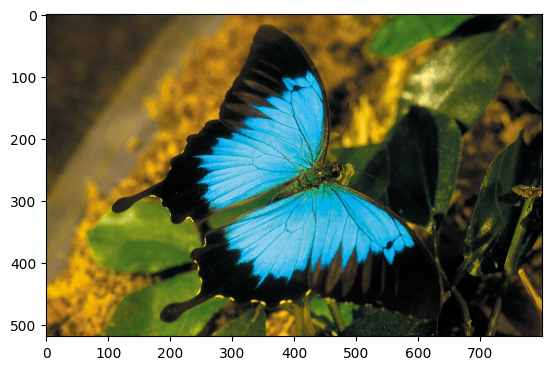

In [5]:
# Load and display image for testing
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')/255.0
plt.imshow(im[:,:,[2,1,0]])
plt.show()

### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [6]:
def kmeans(im, iters=10, K=3, plot=False):
    
    seed = 42
    np.random.seed(seed)
    
    h, w, c = im.shape
    
    # Flatten into Nx3 vector of pixels
    pixels = im.reshape(-1, 3).astype(np.float32)
    
    # Select K random colour centroids
    random_idx = np.random.choice(pixels.shape[0], K, replace=False)
    centroids = pixels[random_idx].copy()
    
    loss = []
    
    for j in range(iters):
        
        # Assign each pixel to nearest centroid (squared Euclidean distance)
        distances = np.sum((pixels[:, np.newaxis, :] - centroids[np.newaxis, :, :])**2, axis=2)
        cluster_indices = np.argmin(distances, axis=1)
        
        # Update centroid locations using new cluster assignments
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            cluster_pixels = pixels[cluster_indices == k]
            if len(cluster_pixels) > 0:
                new_centroids[k] = np.mean(cluster_pixels, axis=0)
            else:
                new_centroids[k] = pixels[np.random.choice(pixels.shape[0])]
        centroids = new_centroids
        
        # Store current loss: sum of squared distances to assigned centroid
        loss.append(np.sum((pixels - centroids[cluster_indices])**2))
        
        # Convert cluster indices to 2D image
        cluster_idx_image = cluster_indices.reshape(h, w)
        
        # Create quantised image â€” keep as float [0,1], do NOT convert to uint8
        quantised_image = centroids[cluster_indices].reshape(h, w, 3)
        quantised_image = np.clip(quantised_image, 0, 1)
        
        if plot:
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(cluster_idx_image, cmap='viridis')
            plt.title(f'Cluster indices, iter={j+1}')
            plt.subplot(1, 2, 2)
            plt.imshow(quantised_image[:, :, [2, 1, 0]])
            plt.title(f'Quantised image, iter={j+1}')
            plt.tight_layout()
            plt.show()
    
    return loss, cluster_idx_image, quantised_image


Iterations = 15, K = 5, final loss = 7179.9282


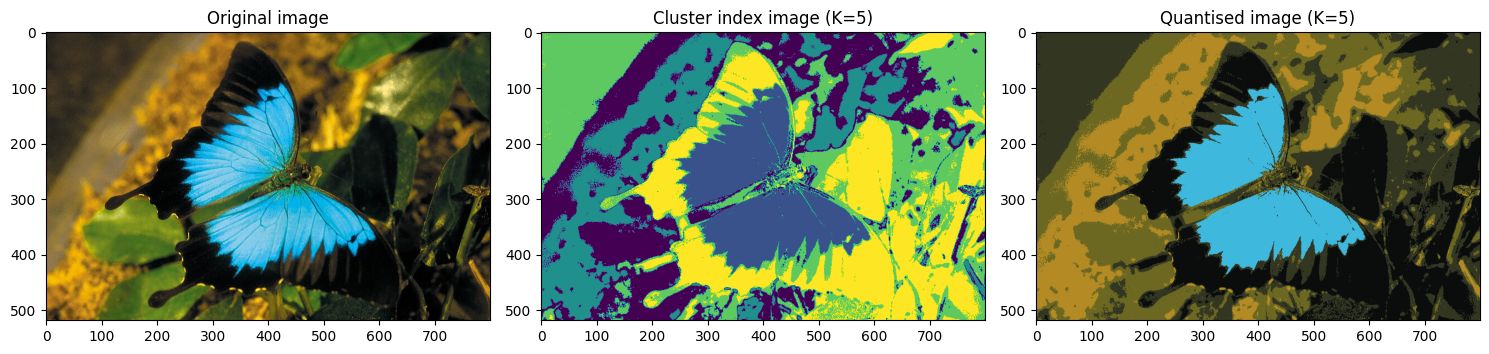

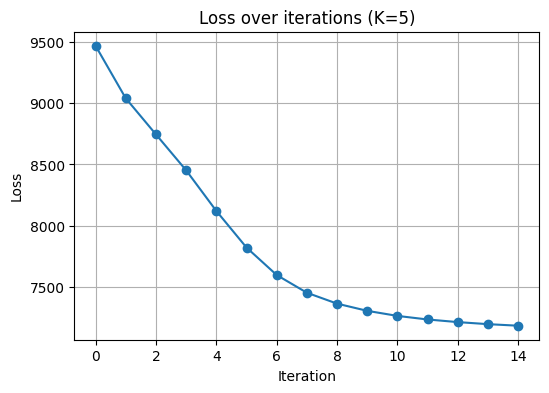

In [7]:
test_L = 15
test_K = 5

loss, cluster_idx_image, quantised_image = kmeans(im, iters=test_L, K=test_K)

print(f'Iterations = {test_L}, K = {test_K}, final loss = {loss[-1]:.4f}')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(im[:, :, [2, 1, 0]])
plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(cluster_idx_image, cmap='viridis')
plt.title(f'Cluster index image (K={test_K})')
plt.subplot(1, 3, 3)
plt.imshow(quantised_image[:, :, [2, 1, 0]])
plt.title(f'Quantised image (K={test_K})')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(loss, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Loss over iterations (K={test_K})')
plt.grid(True)
plt.show()


K=2, final loss=38413.3164
K=3, final loss=13771.4980
K=5, final loss=7179.9282
K=7, final loss=5714.3936
K=10, final loss=3737.6455


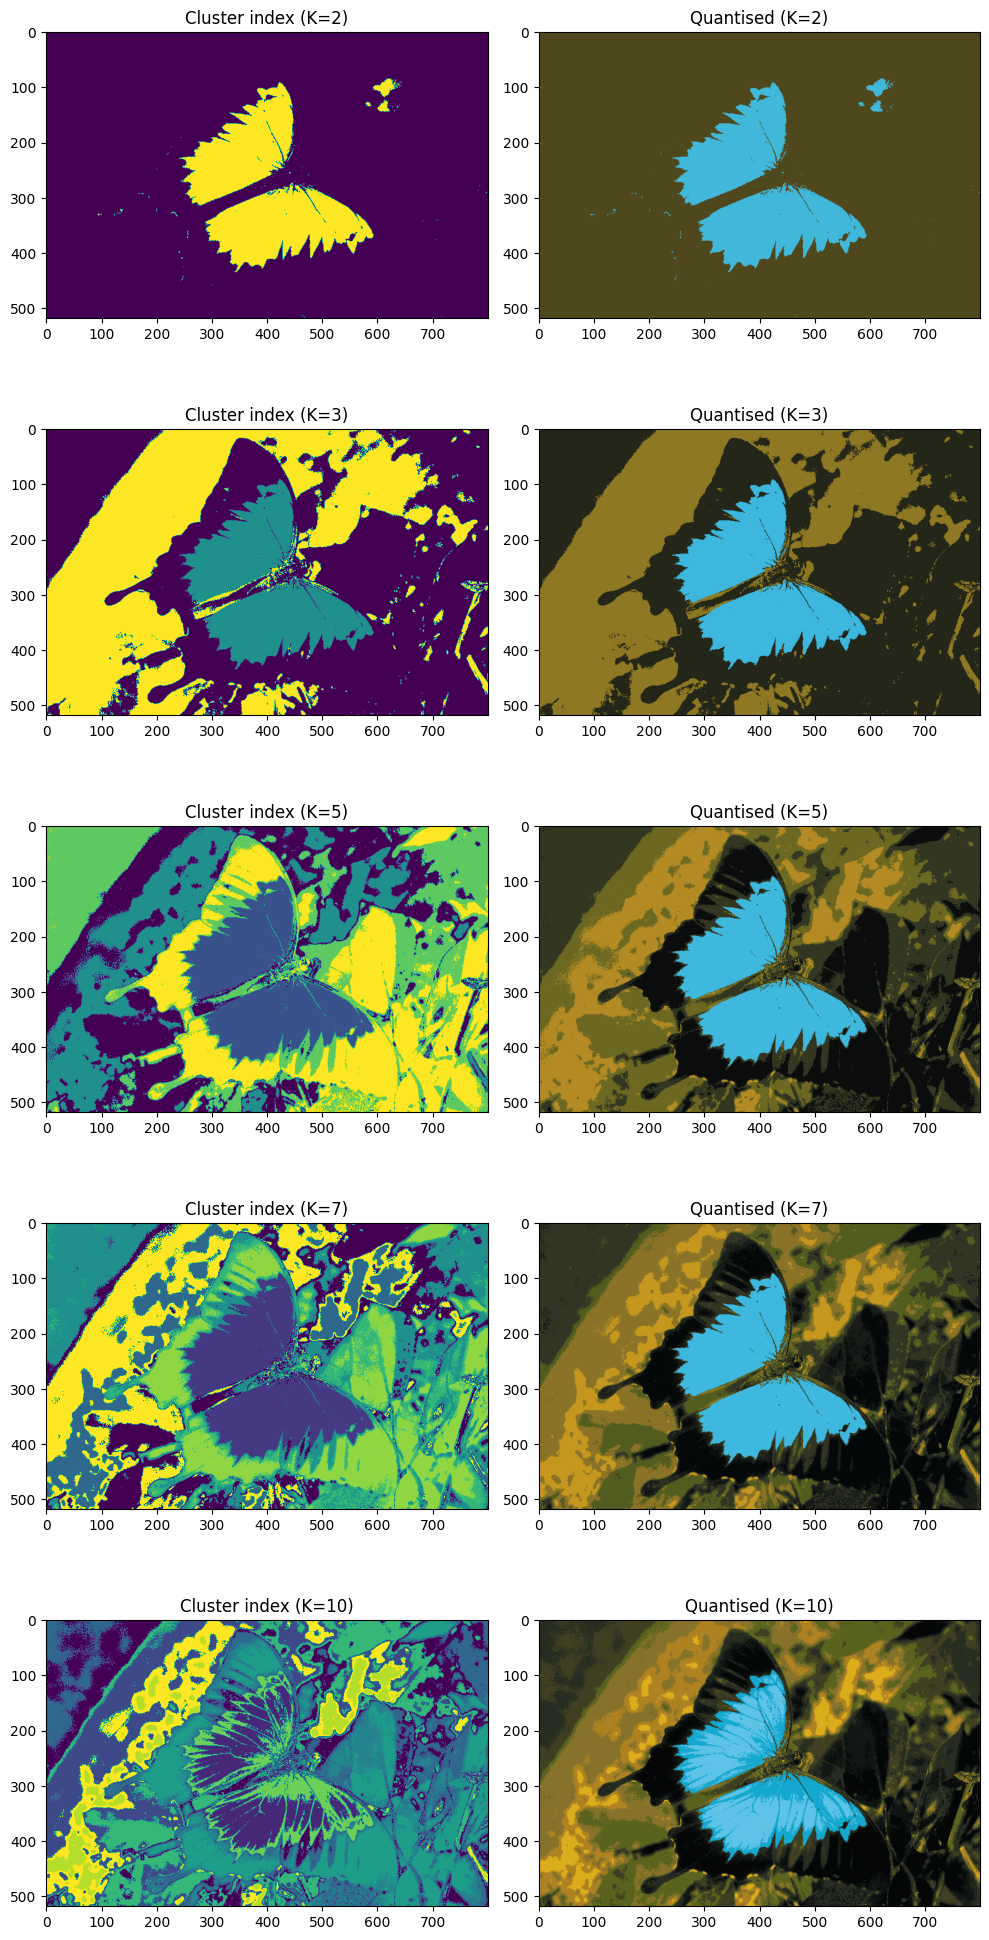

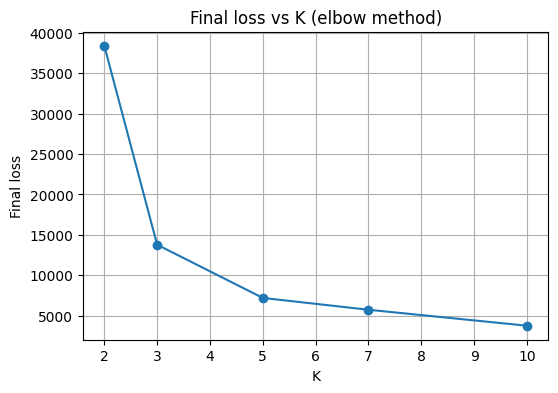

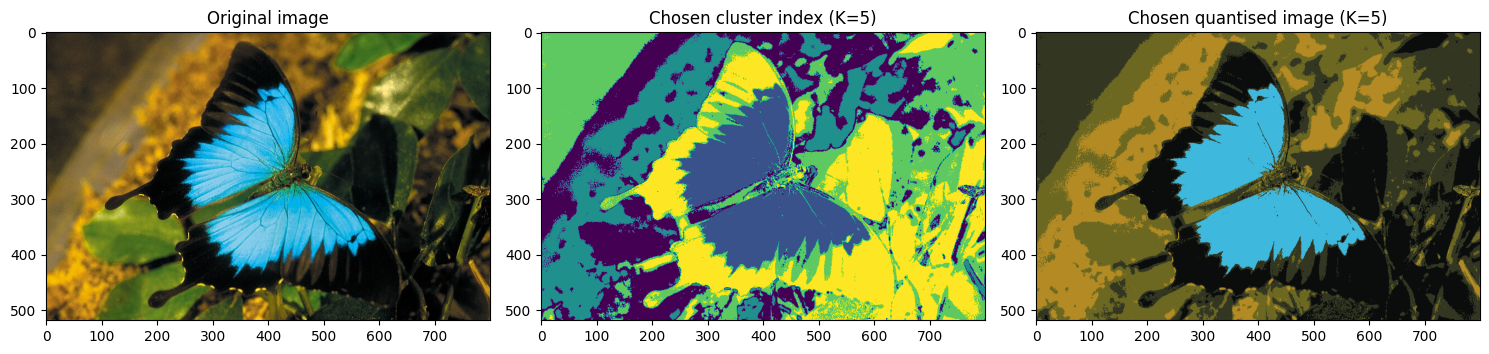

In [8]:
K_values = [2, 3, 5, 7, 10]
iters = 15
all_losses, all_cluster_imgs, all_quantised_imgs = [], [], []

for K in K_values:
    loss, cluster_idx_image, quantised_image = kmeans(im, iters=iters, K=K)
    all_losses.append(loss)
    all_cluster_imgs.append(cluster_idx_image)
    all_quantised_imgs.append(quantised_image)
    print(f'K={K}, final loss={loss[-1]:.4f}')

fig, axes = plt.subplots(len(K_values), 2, figsize=(10, 4*len(K_values)))
for i, K in enumerate(K_values):
    axes[i, 0].imshow(all_cluster_imgs[i], cmap='viridis')
    axes[i, 0].set_title(f'Cluster index (K={K})')
    axes[i, 1].imshow(all_quantised_imgs[i][:, :, [2, 1, 0]])
    axes[i, 1].set_title(f'Quantised (K={K})')
plt.tight_layout()
plt.show()

final_losses = [l[-1] for l in all_losses]
plt.figure(figsize=(6, 4))
plt.plot(K_values, final_losses, marker='o')
plt.xlabel('K')
plt.ylabel('Final loss')
plt.title('Final loss vs K (elbow method)')
plt.grid(True)
plt.show()

# K=5 chosen: elbow visible, good colour separation without over-segmenting
best_K = 5
loss, cluster_idx_image, quantised_image = kmeans(im, iters=iters, K=best_K)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(im[:, :, [2, 1, 0]])
plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(cluster_idx_image, cmap='viridis')
plt.title(f'Chosen cluster index (K={best_K})')
plt.subplot(1, 3, 3)
plt.imshow(quantised_image[:, :, [2, 1, 0]])
plt.title(f'Chosen quantised image (K={best_K})')
plt.tight_layout()
plt.show()


### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

In [9]:
def kmeans_superpixels(im, iters=10, K=50, coord_scale=50, plot=False):
    
    seed = 42
    np.random.seed(seed)
    
    h, w, c = im.shape
    
    pixels = im.reshape(-1, 3).astype(np.float32)
    
    yy, xx = np.indices((h, w))
    xx = xx.reshape(-1, 1).astype(np.float32) / (w - 1)
    yy = yy.reshape(-1, 1).astype(np.float32) / (h - 1)
    
    # 5D feature vector: [B, G, R, x, y]
    features = np.concatenate([pixels, coord_scale * xx, coord_scale * yy], axis=1)
    
    random_idx = np.random.choice(features.shape[0], K, replace=False)
    centroids = features[random_idx].copy()
    
    loss = []
    
    for j in range(iters):
        
        distances = np.sum((features[:, np.newaxis, :] - centroids[np.newaxis, :, :])**2, axis=2)
        cluster_indices = np.argmin(distances, axis=1)
        
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            cluster_points = features[cluster_indices == k]
            if len(cluster_points) > 0:
                new_centroids[k] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[k] = features[np.random.choice(features.shape[0])]
        centroids = new_centroids
        
        loss.append(np.sum((features - centroids[cluster_indices])**2))
        
        cluster_idx_image = cluster_indices.reshape(h, w)
        
        # Colour channels only, keep as float [0,1]
        quantised_image = centroids[cluster_indices][:, :3].reshape(h, w, 3)
        quantised_image = np.clip(quantised_image, 0, 1)
        
        if plot:
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(cluster_idx_image, cmap='viridis')
            plt.title(f'Cluster indices, iter={j+1}')
            plt.subplot(1, 2, 2)
            plt.imshow(quantised_image[:, :, [2, 1, 0]])
            plt.title(f'Superpixel result, iter={j+1}')
            plt.tight_layout()
            plt.show()
    
    return loss, cluster_idx_image, quantised_image


K=50, scale=50, final loss=3597840.7500


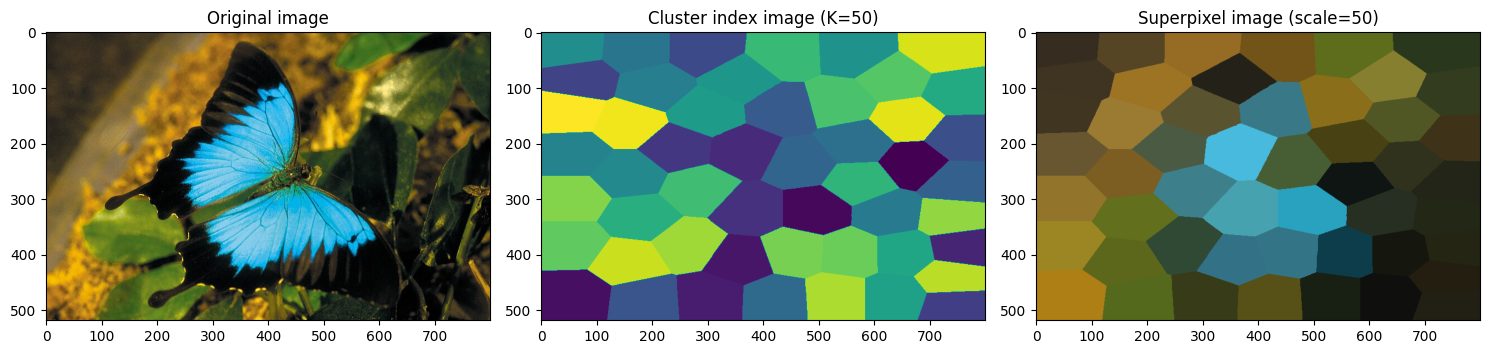

Scale=1, final loss=8119.7070
Scale=20, final loss=602862.3125
Scale=50, final loss=3597840.7500
Scale=100, final loss=14282131.0000


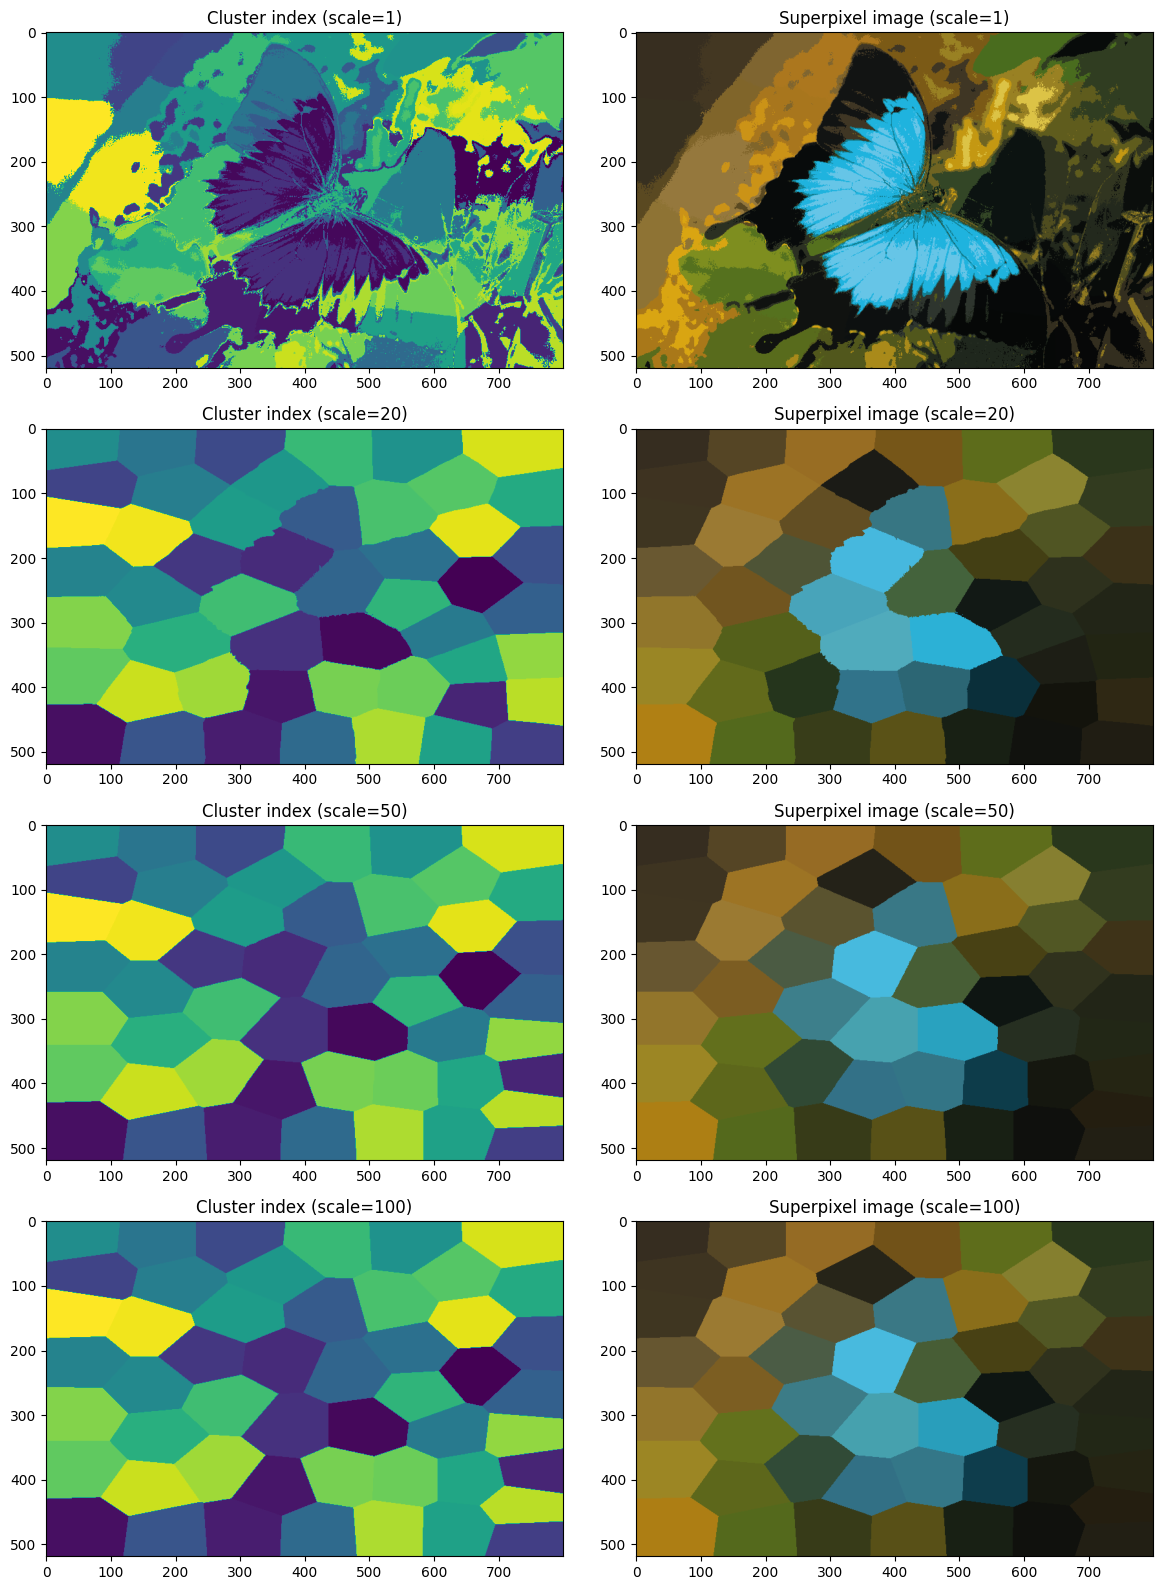

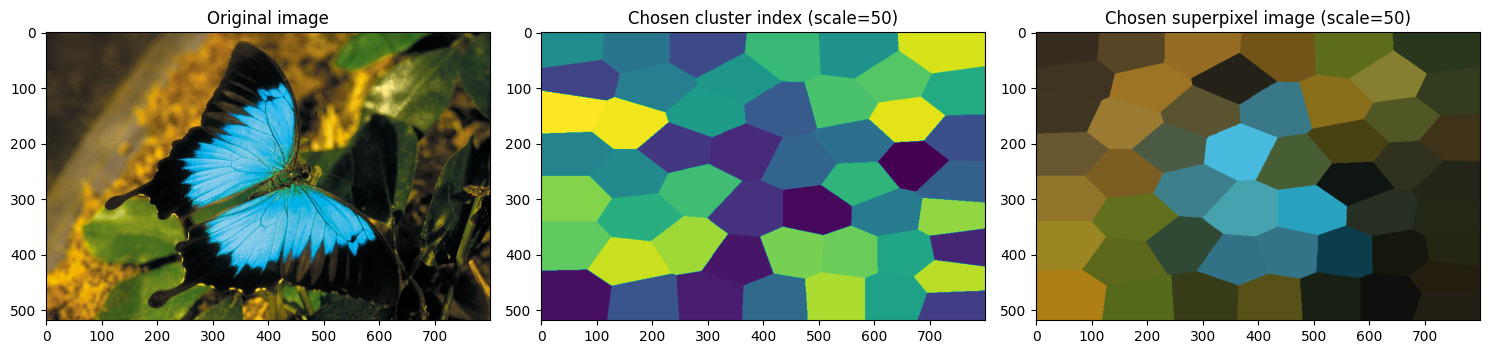

In [10]:
# Test with K=50
loss, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=15, K=50, coord_scale=50)
print(f'K=50, scale=50, final loss={loss[-1]:.4f}')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(im[:, :, [2, 1, 0]])
plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(cluster_idx_image, cmap='viridis')
plt.title('Cluster index image (K=50)')
plt.subplot(1, 3, 3)
plt.imshow(quantised_image[:, :, [2, 1, 0]])
plt.title('Superpixel image (scale=50)')
plt.tight_layout()
plt.show()

# Scale comparison
scales = [1, 20, 50, 100]
K = 50
iters = 15
all_losses, all_cluster_imgs, all_quantised_imgs = [], [], []

for scale in scales:
    loss, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=iters, K=K, coord_scale=scale)
    all_losses.append(loss)
    all_cluster_imgs.append(cluster_idx_image)
    all_quantised_imgs.append(quantised_image)
    print(f'Scale={scale}, final loss={loss[-1]:.4f}')

fig, axes = plt.subplots(len(scales), 2, figsize=(12, 4*len(scales)))
for i, scale in enumerate(scales):
    axes[i, 0].imshow(all_cluster_imgs[i], cmap='viridis')
    axes[i, 0].set_title(f'Cluster index (scale={scale})')
    axes[i, 1].imshow(all_quantised_imgs[i][:, :, [2, 1, 0]])
    axes[i, 1].set_title(f'Superpixel image (scale={scale})')
plt.tight_layout()
plt.show()

# scale=50 chosen: connected superpixels with good colour sensitivity
best_scale = 50
loss, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=iters, K=K, coord_scale=best_scale)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(im[:, :, [2, 1, 0]])
plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(cluster_idx_image, cmap='viridis')
plt.title(f'Chosen cluster index (scale={best_scale})')
plt.subplot(1, 3, 3)
plt.imshow(quantised_image[:, :, [2, 1, 0]])
plt.title(f'Chosen superpixel image (scale={best_scale})')
plt.tight_layout()
plt.show()


## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


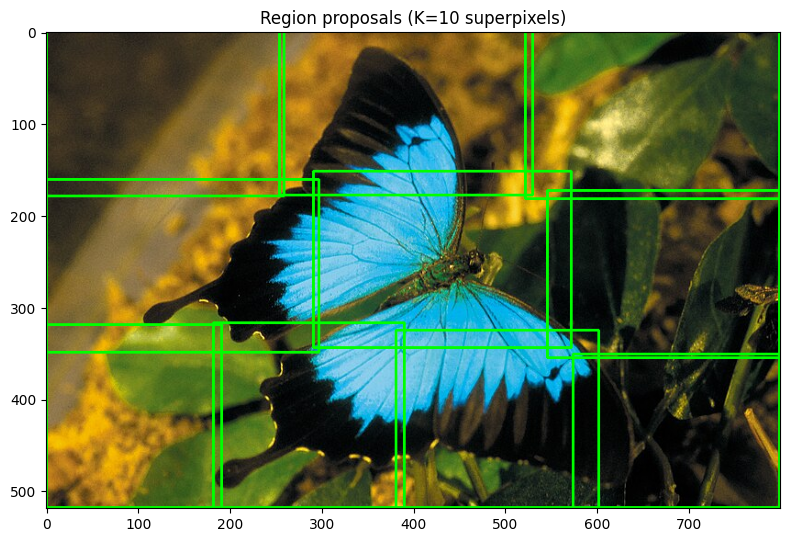

In [11]:
# Segment into 10 superpixels
loss, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=15, K=10, coord_scale=50)

# Copy original image to draw on â€” keep as float [0,1]
region_image = im.copy()

# Find bounding box of each superpixel and draw rectangle
for k in range(10):
    ys, xs = np.where(cluster_idx_image == k)
    
    if len(xs) == 0 or len(ys) == 0:
        continue
    
    x_min, x_max = int(np.min(xs)), int(np.max(xs))
    y_min, y_max = int(np.min(ys)), int(np.max(ys))
    
    # cv2.rectangle on float [0,1] image â€” colour in [0,1] range
    cv2.rectangle(region_image, (x_min, y_min), (x_max, y_max), (0, 1, 0), 2)

plt.figure(figsize=(8, 6))
plt.imshow(region_image[:, :, [2, 1, 0]])
plt.title('Region proposals (K=10 superpixels)')
plt.tight_layout()
plt.show()


## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.

**Task 1 – K-means colour clustering**

We implemented k-means by flattening the image into an Nx3 array of pixel colours, randomly sampling K pixels as initial centroids, then iterating: assigning every pixel to its nearest centroid (squared Euclidean distance) and updating each centroid to the mean of its assigned pixels. This is the hard-assignment limit of the EM algorithm from the Week 7 GMM lectures — rather than computing soft probabilistic responsibilities, every pixel gets assigned to exactly one centroid. Because k-means optimises a non-convex objective, it is only guaranteed to converge to a local minimum, which is why initialisation matters.

The loss vs iterations plot shows a steep drop in the first 5–6 iterations followed by a plateau around iteration 10–12, confirming convergence well within our 15-iteration budget. Early iterations make large corrections from random starting positions; later ones make only fine adjustments as centroids stabilise.

To select K we applied the elbow method across K = [2, 3, 5, 7, 10], plotting final loss against K. Loss always decreases with K, so the elbow identifies the point of diminishing returns where adding a cluster stops meaningfully improving colour representation. We chose K=5 — it sits at this elbow and visually separates the blue wings, dark body, orange patches, yellow soil and green leaves into distinct clusters. K=7 and K=10 split regions that are already well-separated, adding complexity without interpretive value.

**Task 2 – Superpixels with colour and spatial features**

We extended the feature vector from 3D [B, G, R] to 5D [B, G, R, x_scaled, y_scaled] by normalising pixel coordinates to [0, 1] then multiplying by coord_scale. This normalisation is critical: without it, raw pixel coordinates (0–760) would dwarf colour values (0–1) at any scale, making coord_scale meaningless. With normalisation, coord_scale becomes a genuine weight controlling how much spatial proximity contributes to cluster distance relative to colour.

We tested scales of 1, 20, 50, and 100 with K=50. At scale=1 the spatial term is negligible — clustering degenerates to colour-only k-means, producing fragmented, disconnected regions that violate the core superpixel requirement. At scale=100, location dominates and the result approaches a regular grid, ignoring colour entirely. Scale=50 produced 50 spatially connected regions that still respect colour boundaries, cleanly separating wings, body and background. Physically, coord_scale sets the effective radius in pixel-space at which two pixels of identical colour are as "distant" as two pixels of maximum colour difference but identical location.

**Task 3 – Region proposals**

With K=10 and scale=50, the 10 superpixels cover the main semantic regions of the image. For each cluster we used np.where to get all pixel locations, extracted min/max x and y for the bounding box corners, and drew rectangles with cv2.rectangle. The proposals cover wings, body and background regions sensibly.

The key limitation is that axis-aligned bounding boxes enclose the full spatial extent of each superpixel, inflating the box beyond the actual object boundary for irregular shapes. Two clear improvements would be: (1) K-means++ initialisation — seeding centroids proportional to squared distance from existing ones — to reduce sensitivity to random starts and improve consistency; (2) post-processing with connected components to enforce spatial continuity, which would allow using lower coord_scale values while still guaranteeing valid superpixels.